In [21]:
#pip install randomcolor

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

from sklearn.preprocessing import StandardScaler
import randomcolor as rc

In [23]:
# os.chdir('//Users//Justin//Desktop//Coding:Projects//Kaggle_Competitions//Predicting the Beats-per-Minute of Songs')
# os.getcwd()

# Reading in the data

In [24]:
train = pd.read_csv('Data/train.csv')
test = pd.read_csv('Data/test.csv')

print(f'Train---{train.shape}\nTest---{test.shape}')

Train---(524164, 11)
Test---(174722, 10)


# EDA

### Train

In [25]:
train_p1_drop = train.drop(columns='id')

In [26]:
train_p1_drop.head()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [27]:
train_p1_drop.info()
train_p1_drop.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524164 entries, 0 to 524163
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   RhythmScore                524164 non-null  float64
 1   AudioLoudness              524164 non-null  float64
 2   VocalContent               524164 non-null  float64
 3   AcousticQuality            524164 non-null  float64
 4   InstrumentalScore          524164 non-null  float64
 5   LivePerformanceLikelihood  524164 non-null  float64
 6   MoodScore                  524164 non-null  float64
 7   TrackDurationMs            524164 non-null  float64
 8   Energy                     524164 non-null  float64
 9   BeatsPerMinute             524164 non-null  float64
dtypes: float64(10)
memory usage: 40.0 MB


,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,0.632843,-8.379014,0.074443,0.262913,0.117690,0.178398,0.555843,241903.692949,0.500923,119.034899
std,0.156899,4.616221,0.049939,0.223120,0.131845,0.118186,0.225480,59326.601501,0.289952,26.468077
min,0.076900,-27.509725,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067,46.718000
25%,0.515850,-11.551933,0.023500,0.069413,0.000001,0.077637,0.403921,207099.876625,0.254933,101.070410
50%,0.634686,-8.252499,0.066425,0.242502,0.074247,0.166327,0.564817,243684.058150,0.511800,118.747660
75%,0.739179,-4.912298,0.107343,0.396957,0.204065,0.268946,0.716633,281851.658500,0.746000,136.686590
max,0.975000,-1.357000,0.256401,0.995000,0.869258,0.599924,0.978000,464723.228100,1.000000,206.037000


### 

In [109]:
# Visuals functions
def histo_plt(df):
    plt.figure(figsize=(8,20))
    for num, col in enumerate(df.columns,1):
        plt.subplot(len(df.columns),2,num)
        plt.hist(df[col], color=rc.RandomColor().generate(hue='green'), edgecolor='black')
        plt.title(col)
    plt.tight_layout()
    plt.show()

def box_plt(df):
    plt.figure(figsize=(8,20))
    for num, col in enumerate(df.columns,1):
        plt.subplot(len(df.columns),2,num)
        plt.boxplot(df[col])
        plt.title(col)
    plt.tight_layout()
    plt.show()

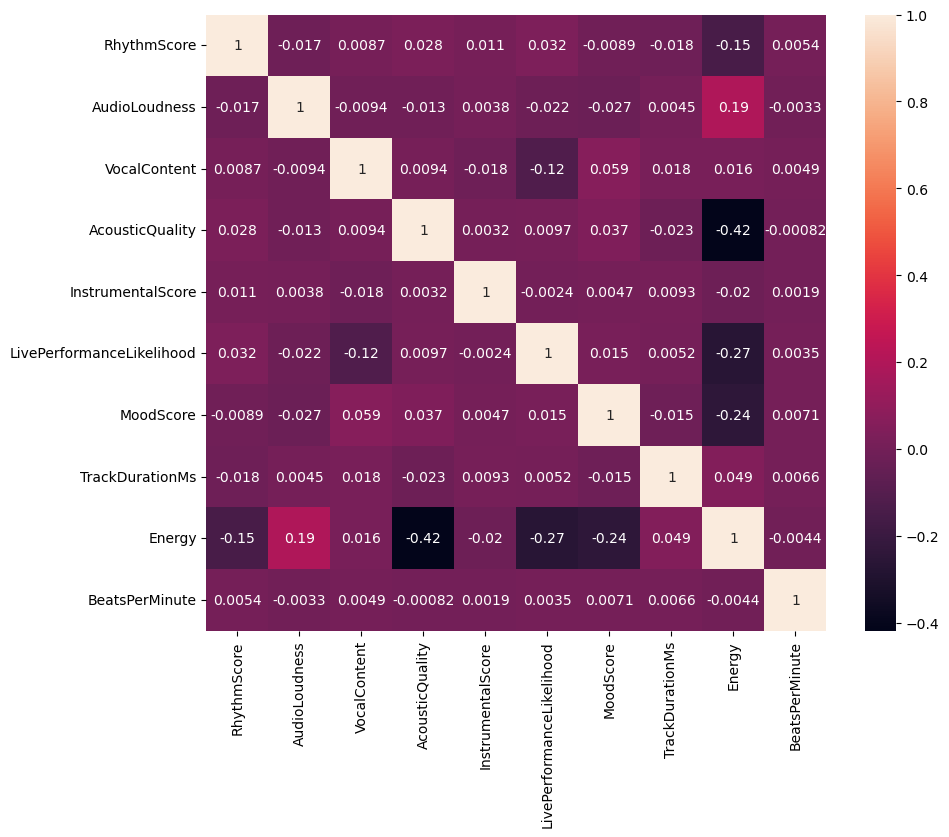

In [29]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_p1_drop.corr(), annot= True, linecolor='black')
plt.show()

The dataset used in the correlation chart also had histogram charts created. Many of the visuals were skewed leading to the follow steps of caluclating the skew values and taking other steps to create more "normal" data.

In [35]:
train_skew = train_p1_drop.skew()

In [36]:
train_p1_drop.skew()

RhythmScore                  0.168155
AudioLoudness               -0.308514
VocalContent                 0.789112
AcousticQuality              0.785966
InstrumentalScore            1.036285
LivePerformanceLikelihood    0.393322
MoodScore                   -0.268820
TrackDurationMs             -0.190483
Energy                      -0.030344
BeatsPerMinute               0.071550
dtype: float64

In [100]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

best_skew = {}
skew_transf_df = pd.DataFrame()

for key, val in train_skew.items():
    skew_stage = {}
    no_trans = val
    log_trans = np.log(train_p1_drop[key]).skew()
    sqrt_trans = np.sqrt(train_p1_drop[key]).skew()

    #Adding above cols to the empty dict
    skew_stage['Norm'] = val
    skew_stage['Log'] = log_trans
    skew_stage['Sqrt'] = sqrt_trans

    # Taking the absolute values of the values and storing the respective key and new value in a new dictionary
    abs_dict = {k: abs(v) for k, v in skew_stage.items()}

    # Grabbing key for the minimum value of all key, value pairs
    top_key = min(abs_dict, key=abs_dict.get)
    
    # Adding the minimum value pair to the best performer dict. Using the key to grab the corresponding value
    best_skew[top_key] = skew_stage[top_key]

    # This function will make the necessary calculations (or not) and apply to a dataframe
    if top_key == 'Norm' :
        skew_transf_df[key] = train_p1_drop[key]
    elif top_key == 'Log' :
        skew_transf_df[f'Log-{key}'] = np.log(train_p1_drop[key])
    elif top_key == 'Sqrt' :
        skew_transf_df[f'Sqrt-{key}'] = np.sqrt(train_p1_drop[key])

    

In [101]:
print(f'Original - {train_p1_drop.shape}')
print(f'Skew Corrected - {skew_transf_df.shape}')

Original - (524164, 10)
Skew Corrected - (524164, 10)


In [102]:
df_list_test = [train_p1_drop, skew_transf_df]

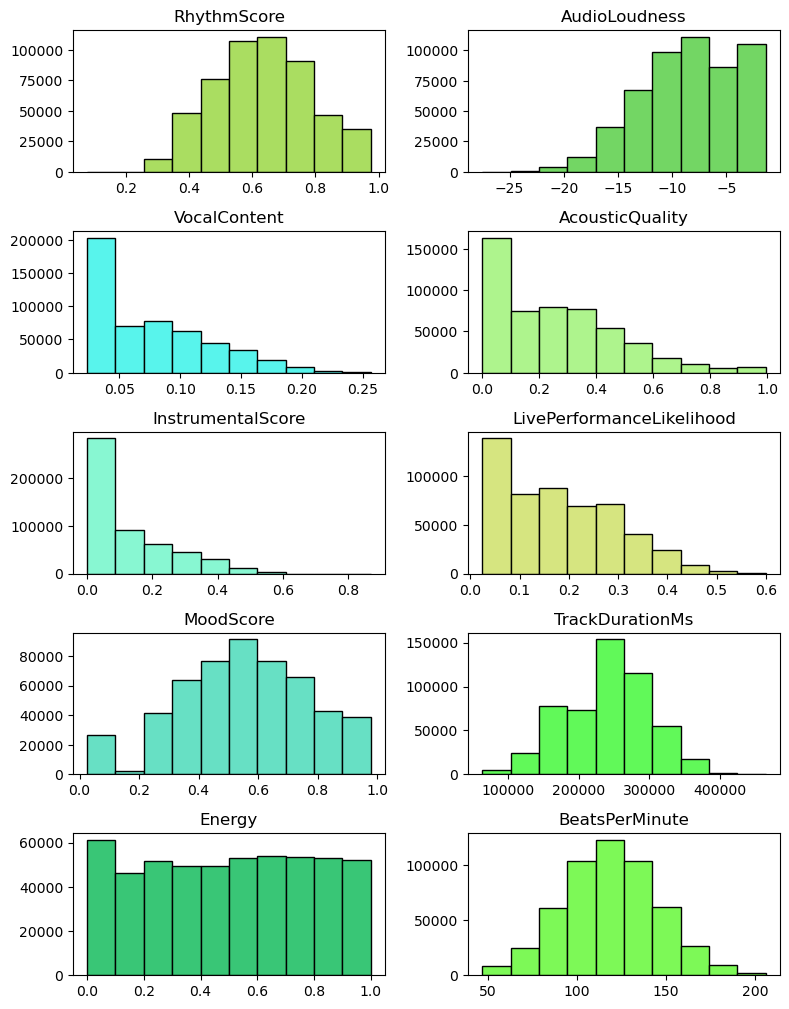

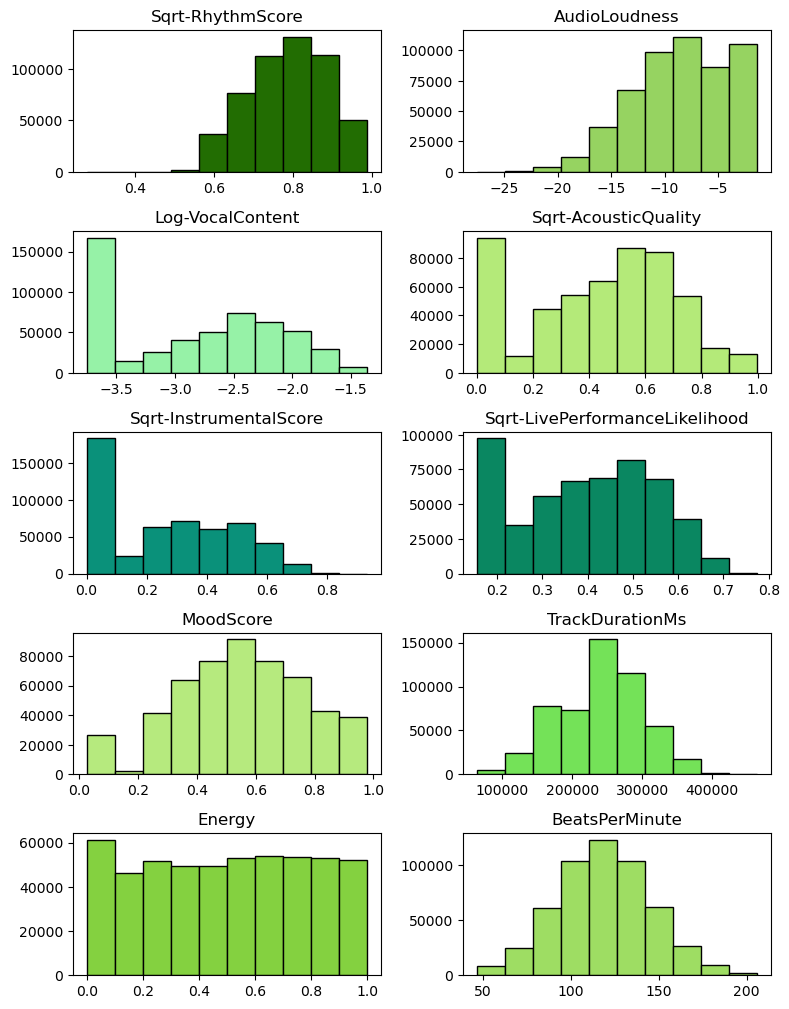

In [104]:
for d in df_list_test:
    histo_plt(d)

In [106]:
for d in df_list_test:
    print(d.skew())

RhythmScore                  0.168155
AudioLoudness               -0.308514
VocalContent                 0.789112
AcousticQuality              0.785966
InstrumentalScore            1.036285
LivePerformanceLikelihood    0.393322
MoodScore                   -0.268820
TrackDurationMs             -0.190483
Energy                      -0.030344
BeatsPerMinute               0.071550
dtype: float64
Sqrt-RhythmScore                 -0.107754
AudioLoudness                    -0.308514
Log-VocalContent                 -0.041971
Sqrt-AcousticQuality             -0.305228
Sqrt-InstrumentalScore            0.180484
Sqrt-LivePerformanceLikelihood   -0.162745
MoodScore                        -0.268820
TrackDurationMs                  -0.190483
Energy                           -0.030344
BeatsPerMinute                    0.071550
dtype: float64


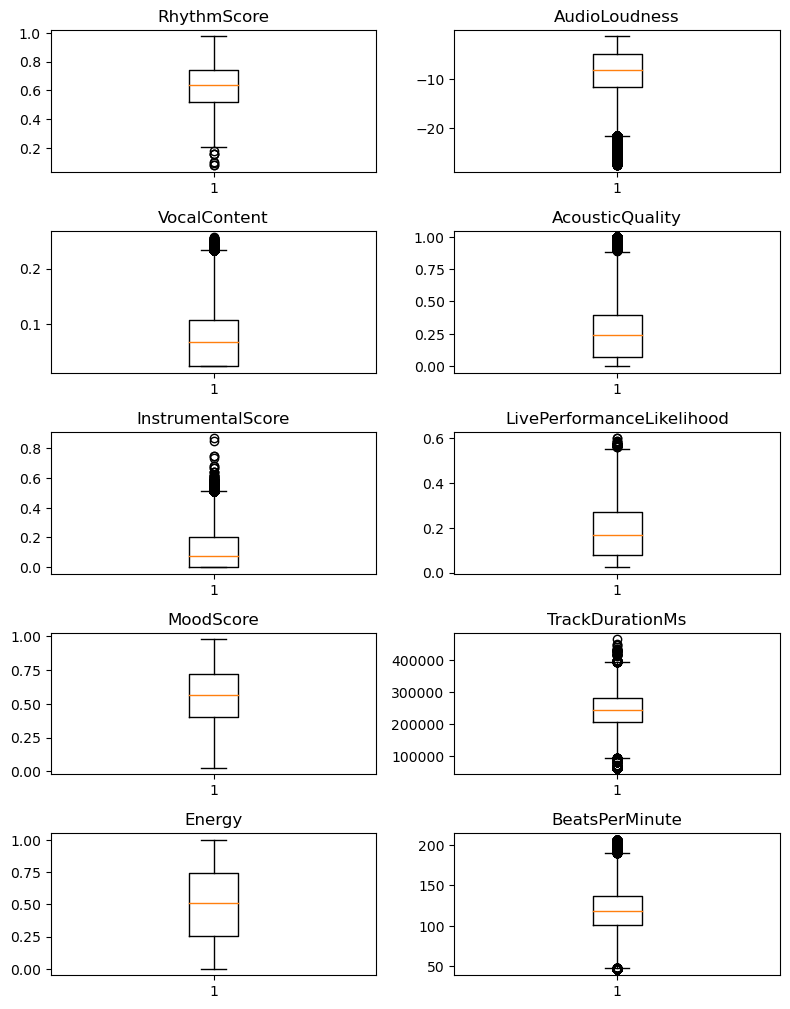

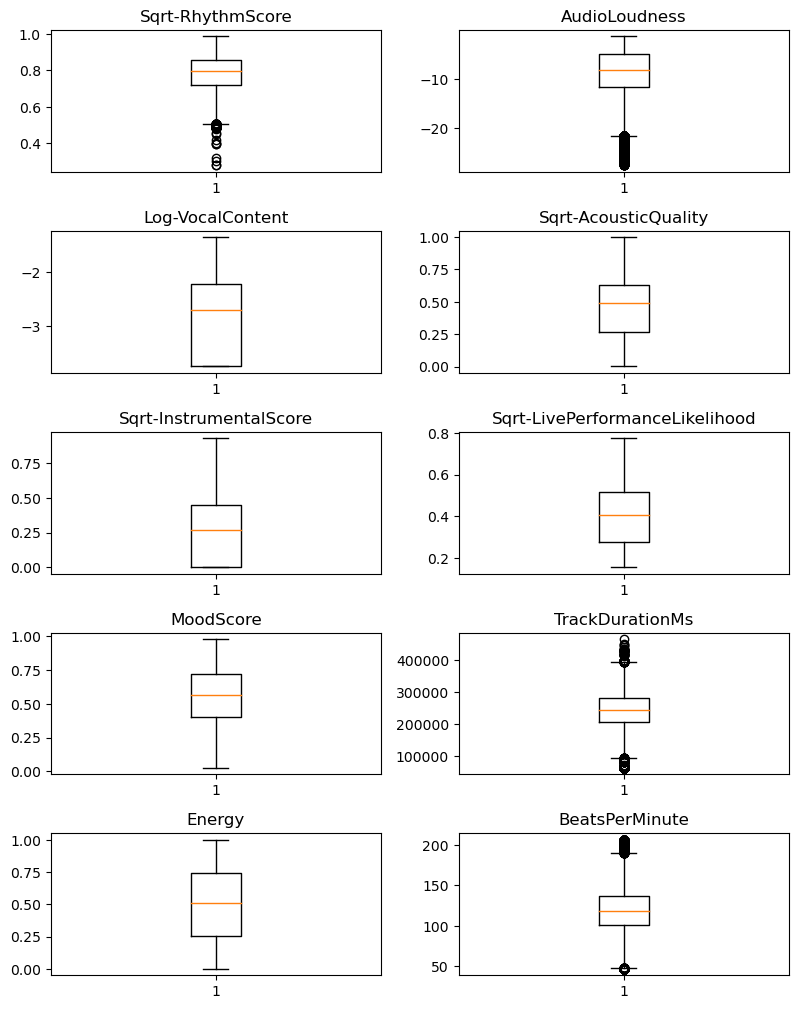

In [110]:
for d in df_list_test:
    box_plt(d)

In [112]:
skew_transf_df.describe()

,Sqrt-RhythmScore,AudioLoudness,Log-VocalContent,Sqrt-AcousticQuality,Sqrt-InstrumentalScore,Sqrt-LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,0.789231,-8.379014,-2.843025,0.439202,0.260471,0.394040,0.555843,241903.692949,0.500923,119.034899
std,0.099788,4.616221,0.723402,0.264602,0.223261,0.152088,0.225480,59326.601501,0.289952,26.468077
min,0.277308,-27.509725,-3.750755,0.002315,0.001034,0.155885,0.025600,63973.000000,0.000067,46.718000
25%,0.718227,-11.551933,-3.750755,0.263464,0.001034,0.278634,0.403921,207099.876625,0.254933,101.070410
50%,0.796672,-8.252499,-2.711689,0.492445,0.272484,0.407832,0.564817,243684.058150,0.511800,118.747660
75%,0.859755,-4.912298,-2.231727,0.630045,0.451736,0.518600,0.716633,281851.658500,0.746000,136.686590
max,0.987421,-1.357000,-1.361013,0.997497,0.932340,0.774548,0.978000,464723.228100,1.000000,206.037000


## Model Preparation

In [113]:
# Scaling the features
ss_features = StandardScaler().fit_transform(skew_transf_df.drop(columns='BeatsPerMinute'))

array([[-0.12333974,  0.16075334, -1.25480856, ..., -0.64740531,
         0.82276748,  1.12206188],
       [ 0.10448091, -1.70888505,  0.28371509, ...,  0.42206432,
        -1.30437691, -1.22614282],
       [-0.72071104, -1.64085896,  0.88778481, ..., -0.5853213 ,
        -1.13622201,  0.4267744 ],
       ...,
       [-0.5248562 ,  1.52116217,  0.28120011, ...,  0.13759446,
         1.73538741,  0.75142583],
       [ 0.09031162,  0.20962699,  0.91707741, ..., -0.82912932,
         1.36206526,  1.52902578],
       [ 0.92165306,  0.62712024, -1.25480856, ...,  1.0539477 ,
         1.21305503, -0.9552934 ]])